In [1]:
import logging

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent
from config_local import config


logger = logging.getLogger(__name__)

<h1>Wikispeedia dataset exploratory analysis</h1>

Let's get started by exploring the Wikispeedia dataset. The dataset is composed of six files:

articles.tsv, which contains the list of wikipedia articles


categories.tsv, which contains the list of wikipedia categories


links.tsv, which contains the list of links between articles


paths_finished.tsv, which contains the list of human paths finished by the users


paths_unfinished.tsv, which contains the list of human paths unfinished by the users


shortest-path-distance-matrix.txt, which contains the shortest path distance between each pair of articles


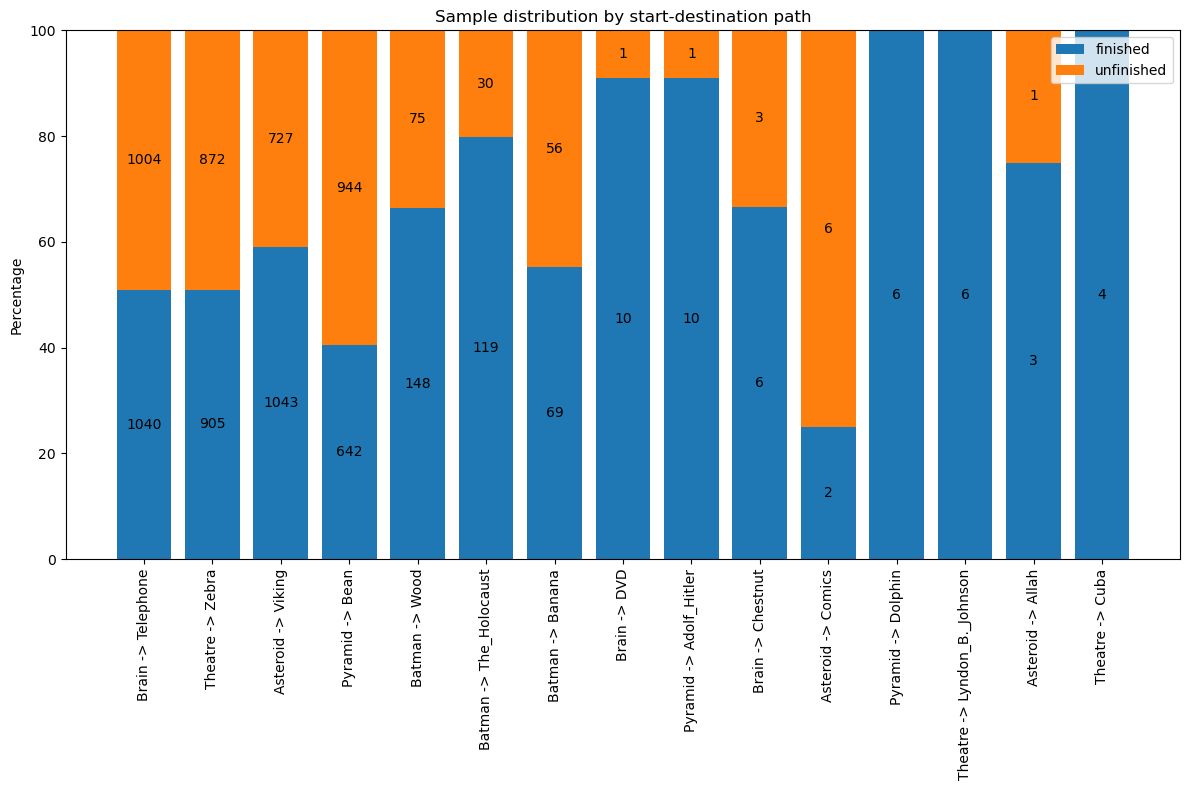

In [12]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

As shown above, we have a few start-destination pairs with a high number of paths.

<h3>Articles</h3>

In [4]:
articles,categories,links = preprocessor.load_data()

In [5]:
# number of articles
print(f'Number of articles: {len(articles)}')

Number of articles: 4604


<h3>Links</h3>  

No article has no outgoing link nor is unreacheable. On average, each article has 26 links to other articles. 

In [6]:
print(links['linkSource'].value_counts().describe())
print(links['linkTarget'].value_counts().describe())

count    4587.000000
mean       26.135165
std        24.194229
min         1.000000
25%        11.000000
50%        19.000000
75%        33.000000
max       294.000000
Name: count, dtype: float64
count    4135.000000
mean       28.992019
std        65.560574
min         1.000000
25%         4.000000
50%        10.000000
75%        29.000000
max      1551.000000
Name: count, dtype: float64


<h3>Categories</h3>

We have 129 unique categories. Each articles has at most 3 categories. 

In [7]:
categories.describe()

,article,category
count,5204,5204
unique,4598,129
top,Pottery,subject.Countries
freq,3,229


<h3>Paths</h3>

We have access to many paths; there are 51,318 finished paths in total and 24,875 unfinished paths.

In [8]:
#numner of finished vs unfinished paths
print('num of finished paths:', len(df[df['target'].isnull()]))
print('num of unfinished paths:', len(df[df['target'].notnull()]))

num of finished paths: 51318
num of unfinished paths: 24875


some paths have '<' in them, indicating backtracking by human players

we can simply resolve them by skipping back to the previous article and continuing from there

In [9]:
df[df['path'].astype(str).str.contains('<')].head(10)['path']

10    14th_century;Time;Science;Nature;Weather;Sunli...
13    14th_century;Renaissance;Empiricism;Nature;Wea...
14    14th_century;Renaissance;Leonardo_da_Vinci;Wat...
16    14th_century;Europe;Republic_of_Ireland;<;<;Eu...
19    14th_century;Time;Physics;<;Day;Sun;Sunlight;U...
36    14th_century;England;London;Spanish_Armada;Eng...
41    14th_century;Europe;<;England;<;Christianity;A...
42    2004_Atlantic_hurricane_season;U.S._state;Unit...
47    2004_Atlantic_hurricane_season;El_Ni%C3%B1o-So...
49    2004_Atlantic_hurricane_season;Atlantic_Ocean;...
Name: path, dtype: object

In [46]:
preprocessor.resolve_all_parsed_paths(df)

In [13]:
#check if all '<' are resolved
print('num of paths with < after resolution:', df['path'].astype(str).str.contains('<').sum())

num of paths with < after resolution: 0


Some finished paths have a length of 1, indicating that the player is already at the target article, so we can simply remove those paths


In [47]:
print('num of finished paths with length 1 before removal:', len(df.loc[(df['source'] == 'finished') & (df['num_hops'] == 1)]))

num of finished paths with length 1 before removal: 11


In [48]:
# remove finished paths with length 1
df = df.drop(df.loc[(df['source'] == 'finished') & (df['num_hops'] == 1)].index)

<h3>Difficulties</h3>

Lets get the distribution of difficulties for finished and unfinished paths:

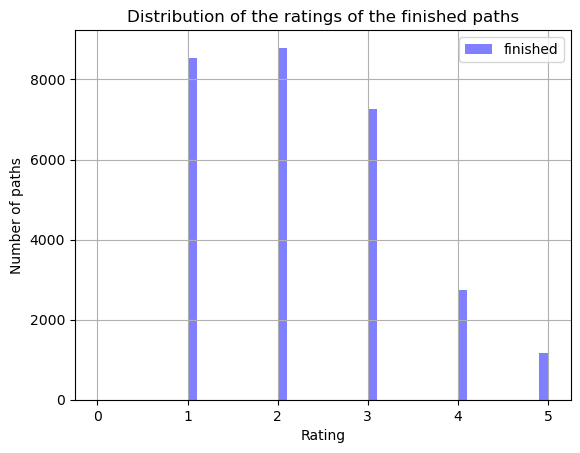

In [11]:
#get the distribution of difficulties for finished and unfinished paths
from matplotlib import pyplot as plt
df['rating'].hist(bins=50, alpha=0.5, label='finished', color='blue', range=(0,5))
plt.title('Distribution of the ratings of the finished paths')
plt.xlabel('Rating')
plt.ylabel('Number of paths')
plt.legend()
plt.show()

The rating distribution is imbalanced, so before conducting our further experiments, we can potentially stratify the dataset based on rating.

<h3>Durations</h3>

We are interested in the distribution of durations for unfinished paths:

/var/folders/9l/mz9v_zqs0dq8klmwm6gs7n9r0000gn/T/ipykernel_92154/3273031189.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


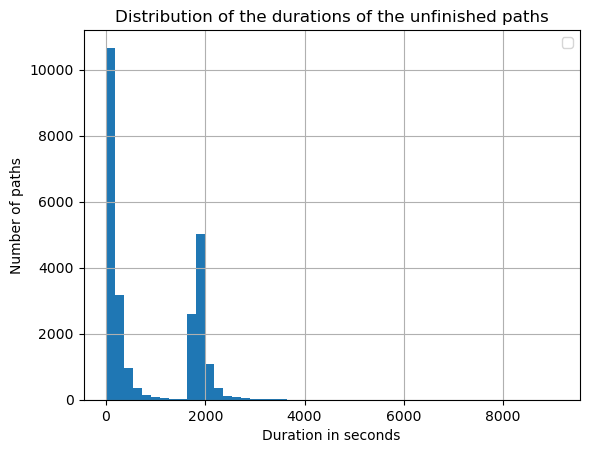

In [73]:
#Duration and rating correlation
df[df['source'] == 'unfinished']['durationInSec'].hist(bins=50)
plt.title('Distribution of the durations of the unfinished paths')
plt.xlabel('Duration in seconds')
plt.ylabel('Number of paths')
plt.legend()
plt.show()



Unfinished paths have two types: restart and timeout. It is two distinct distributions! Timeouts are longer.

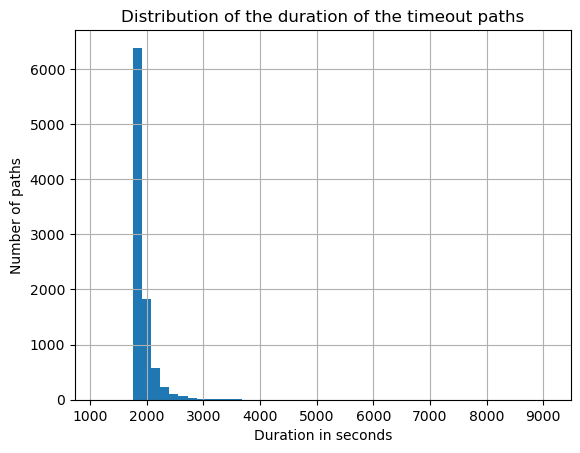

In [60]:
df[(df['source'] == 'unfinished') & (df['type'] == 'timeout')]['durationInSec'].hist(bins=50)
plt.title('Distribution of the duration of the timeout paths')
plt.xlabel('Duration in seconds')
plt.ylabel('Number of paths')
plt.show()

The plot confirms that the duration of timeout paths are an independent distribution from restart paths.

<h3>Semantics</h3>

We can visualize the semantic space of all articles using their embeddings obtained by sentence transformers:   

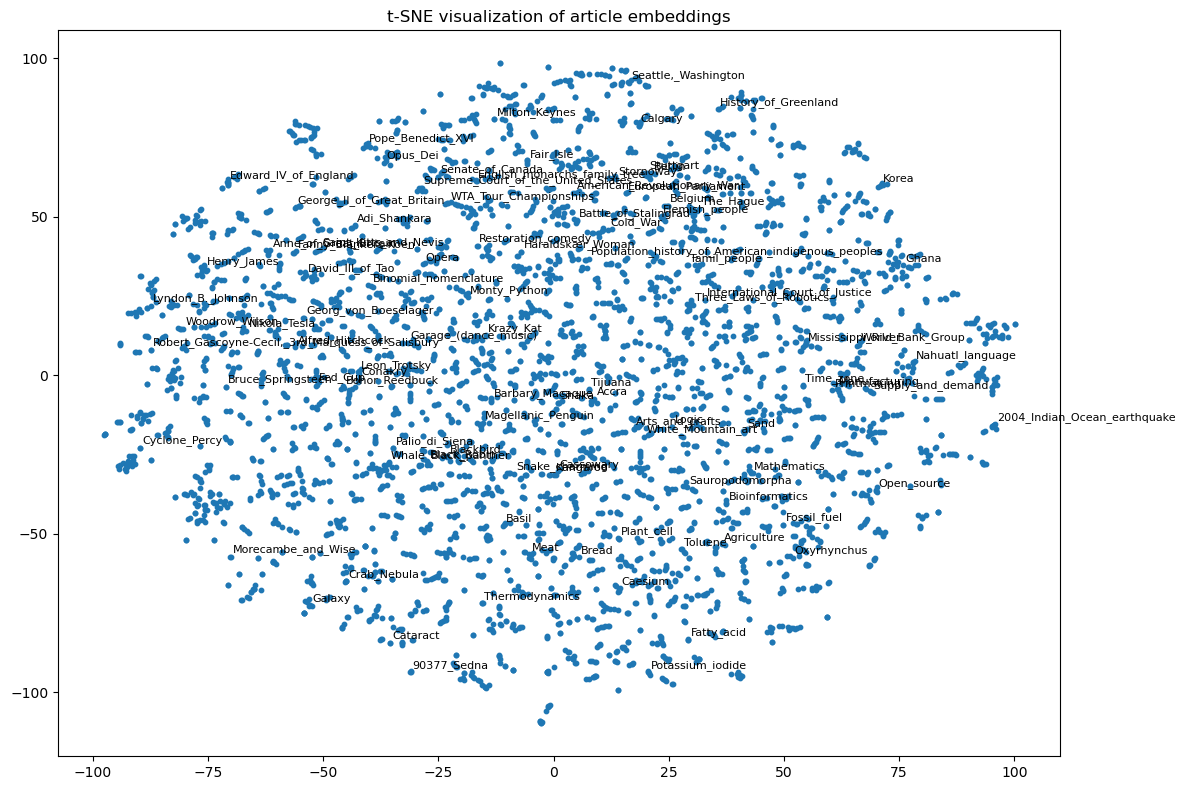

In [74]:
#semantic distribution of articles
visualizer.visualize_semantic_space(
    filename="semantic_space.png",
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt"
)


We can also visualize the association between average hops and average rating for the top start-destination paths. The result indicates that more difficult paths (lower rating) tend to have more hops on average.

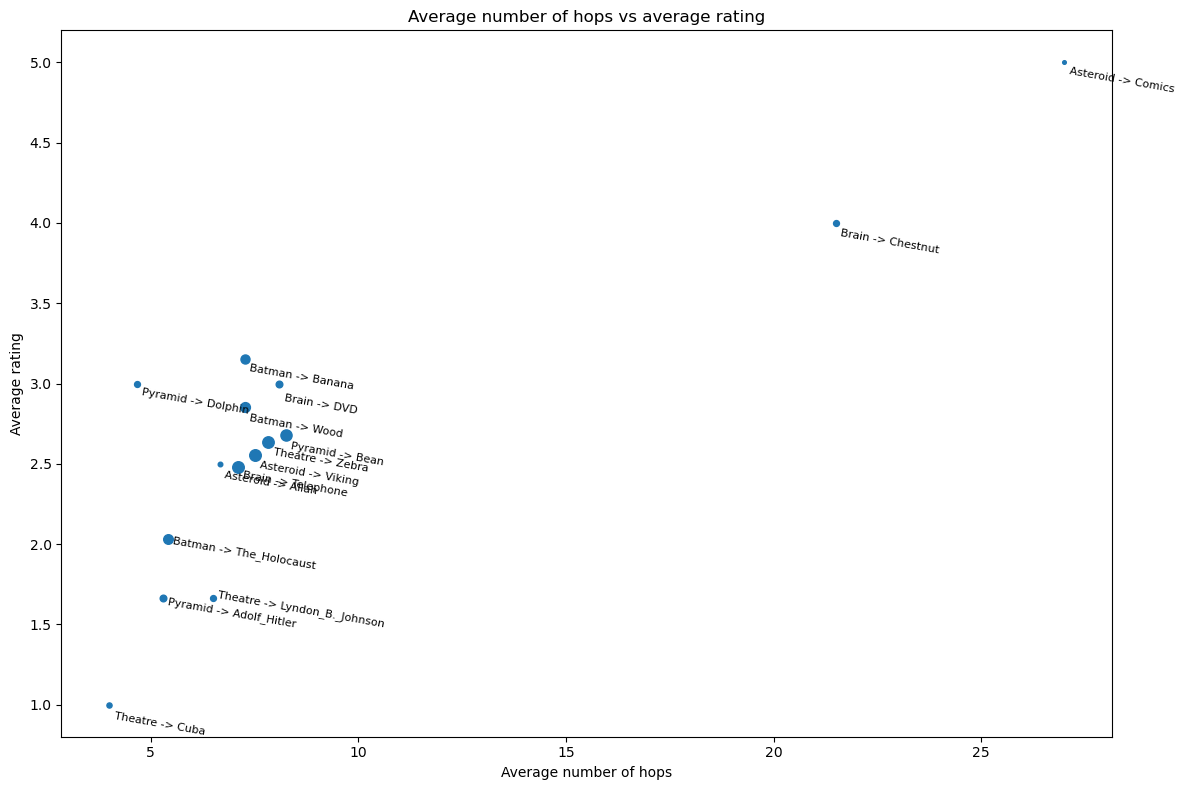

In [75]:
# average hops vs average rating within the above start-destination paths (only for finished paths), scatters are corrected by count [np.log() * 10]
visualizer.visualize_top_k_avg_hops(top_k_df, 'average_hops_vs_average_rating.png')

Below is the hop distribution for paths from Brain to Telephone, only considering finished paths:

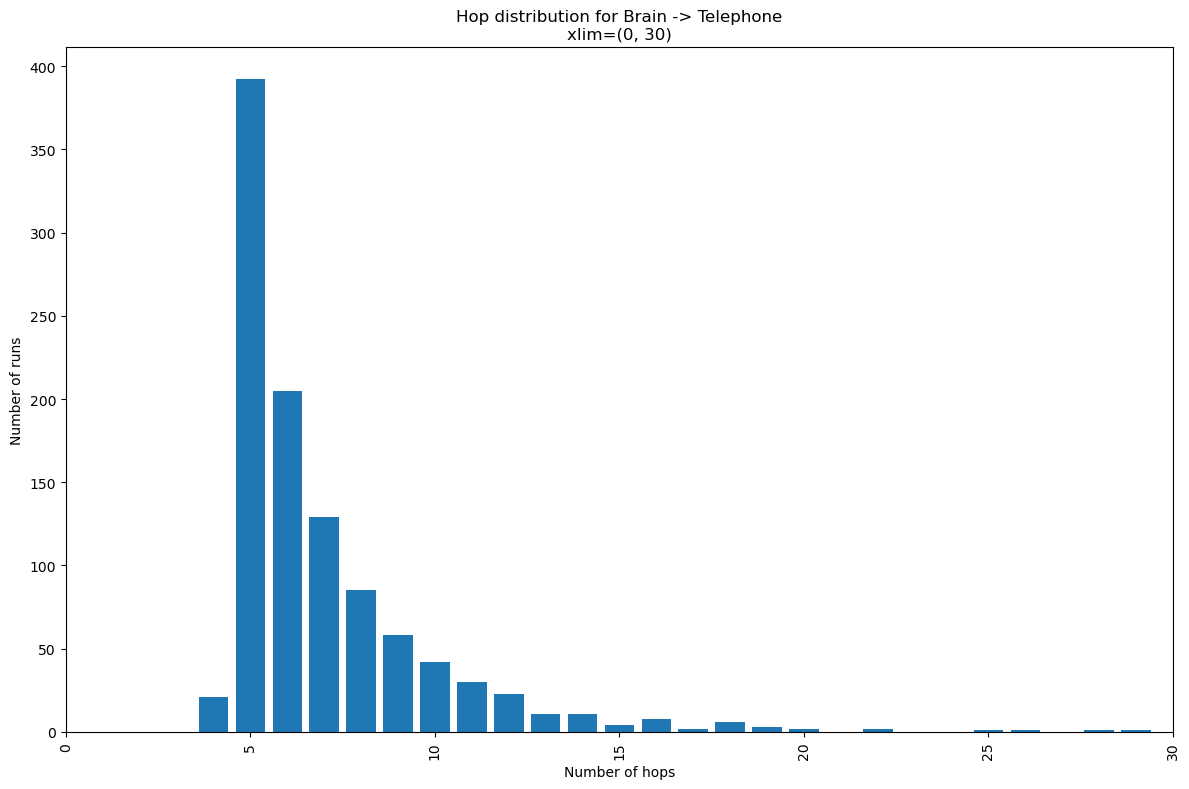

In [9]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

We can see that most paths from Brain to Telephone have around 5 hops.

<h2>Information Gain Analysis</h2>

We can analyze the information gain along the navigation paths from start to destination. The information gain is calculated based on the cosine similarity between current article and target article embeddings obtained from a sentence transformer model. Below is an example of analyzing the information gain for paths from "Brain" to "Telephone".

/Users/richardzhang/project-milestone-p2-group11/semantic.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.gen_output_path(self.embeddings_filenam

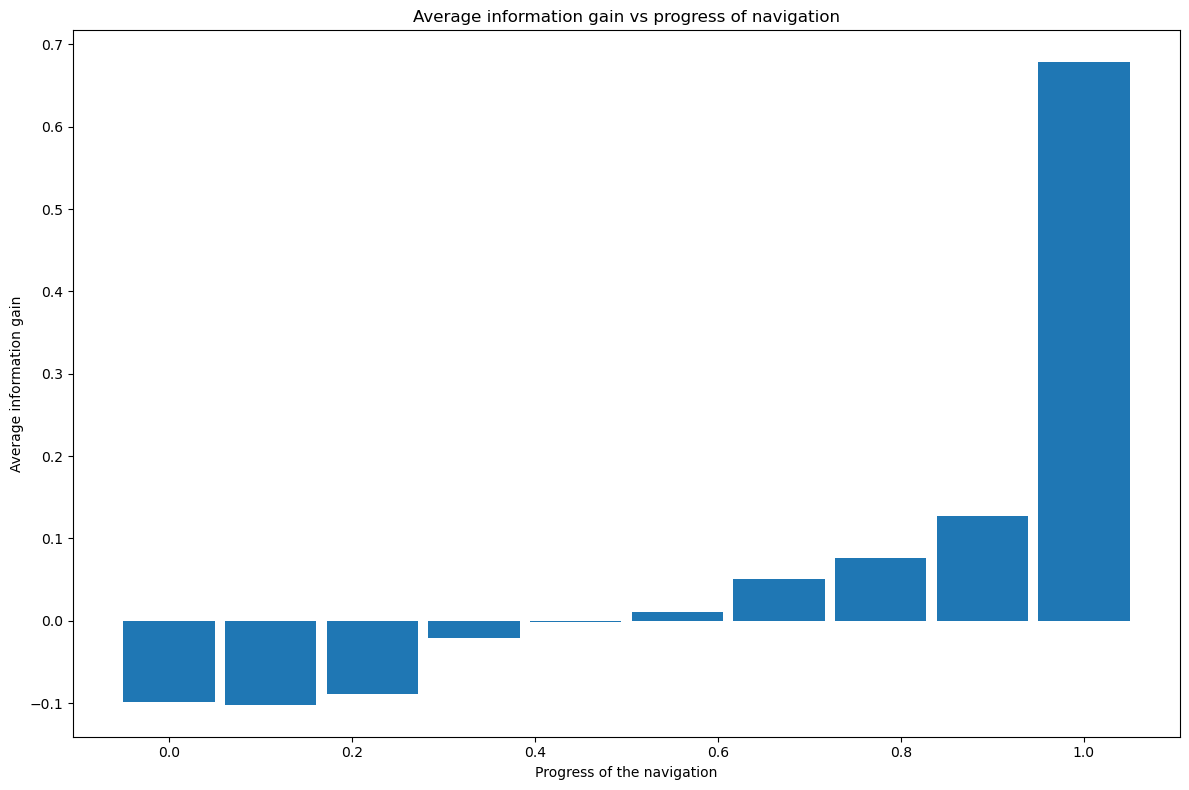

In [5]:
# parse all article titles into a df
articles_df = preprocessor.parse_input_file(config.input_file_articles)

# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles_df)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

Here we have an example test on path generation using a LLM agent. The agent uses the Tree of Thoughts (ToT) approach to generate navigation paths from start to destination.

In [4]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)
llm_tot_path = agent.navigate_tot(start, destination)
f'Path generated by LLM using ToT: {llm_tot_path}'

"Path generated by LLM using ToT: ['Brain', 'Algorithm', 'Computer', 'Telephone']"